In [24]:
!pip install kagglehub

import kagglehub
import pandas as pd
import os

# Download the latest version of the dataset
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

print("Path to dataset files:", path)

# Find the CSV file
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

# Load into pandas Dataframe
df = pd.read_csv(csv_path)

Path to dataset files: /kaggle/input/stroke-prediction-dataset


In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Using categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

# Empty dictionary to store encoders and mappings
label_encoders = {}

# Encoding categorical columns and showing mappings
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

    # Displaying mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"Encoding for column '{col}': {mapping}")

df = df.dropna()

X = df.drop(columns=['id', 'stroke'])  # drop id and target column
y = df['stroke'].values.astype(int)

print(X)
print(X.shape)
print(y)
print(y.shape)



X_array = X.values
print(X_array)

# Normalizing
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_array)

print("Normalized Feature Matrix (X_scaled):")
print(X_scaled)
print(X_scaled.shape)


Encoding for column 'gender': {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Encoding for column 'ever_married': {'No': np.int64(0), 'Yes': np.int64(1)}
Encoding for column 'work_type': {'Govt_job': np.int64(0), 'Never_worked': np.int64(1), 'Private': np.int64(2), 'Self-employed': np.int64(3), 'children': np.int64(4)}
Encoding for column 'Residence_type': {'Rural': np.int64(0), 'Urban': np.int64(1)}
Encoding for column 'smoking_status': {'Unknown': np.int64(0), 'formerly smoked': np.int64(1), 'never smoked': np.int64(2), 'smokes': np.int64(3)}
      gender   age  hypertension  heart_disease  ever_married  work_type  \
0          1  67.0             0              1             1          2   
2          1  80.0             0              1             1          2   
3          0  49.0             0              0             1          2   
4          0  79.0             1              0             1          3   
5          1  81.0             0              0   

In [26]:
import numpy as np

def sigmoid(z):
    """
    Sigmoid activation function.

    Args:
        z (numpy.ndarray): Weighted sum of inputs.

    Returns:
        numpy.ndarray: Sigmoid activation values.
    """
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    """
    Derivative of the sigmoid function.

    Args:
        z (numpy.ndarray): Weighted sum of inputs.

    Returns:
        numpy.ndarray: Derivative of sigmoid.
    """
    return sigmoid(z) * (1 - sigmoid(z))

def relu(z):
    """
    ReLU activation function.

    Args:
        z (numpy.ndarray): Weighted sum of inputs.

    Returns:
        numpy.ndarray: ReLU activation values.
    """

    return np.maximum(0, z)

def relu_derivative(z):
    """
    Derivative of the ReLU function.

    Args:
        z (numpy.ndarray): Weighted sum of inputs.

    Returns:
        numpy.ndarray: Derivative of ReLU.
    """

    return (z > 0).astype(float)


def linear(z):
    """
    Linear activation function.

    Args:
        z (numpy.ndarray): Weighted sum of inputs.

    Returns:
        numpy.ndarray: linear activation values.
    """
    return z

def linear_derivative(z):
    """
    Derivative of the linear function.

    Args:
        z (numpy.ndarray): Weighted sum of inputs.

    Returns:
        numpy.ndarray: Derivative of linear.
    """
    return np.ones(z.shape)
def mean_squared_error(y_true, y_pred):
    """
    Mean squared error loss function.

    Args:
        y_true (numpy.ndarray): True target values.
        y_pred (numpy.ndarray): Predicted values.

    Returns:
        float: Mean squared error.
    """
    return np.mean((y_true - y_pred) ** 2)

In [27]:
class NeuralNetwork:
    def __init__(self, layers, activation='sigmoid'):
        self.layers = layers
        self.activation_name = activation
        self.weights = []
        self.biases = []

        for i in range(len(layers) - 1):
            self.weights.append(np.random.randn(layers[i], layers[i + 1]) * 0.01)
            self.biases.append(np.zeros((1, layers[i + 1])))

        # Choose activation
        if activation == 'sigmoid':
            self.activation = sigmoid
            self.activation_derivative = sigmoid_derivative
        elif activation == 'relu':
            self.activation = relu
            self.activation_derivative = relu_derivative
        elif activation == 'linear':
            self.activation = linear
            self.activation_derivative = linear_derivative
        else:
            raise ValueError("Unsupported activation function. Choose 'sigmoid', 'relu', or 'linear'.")

    def forward(self, x):
        activations = [x]
        z_values = []

        for w, b in zip(self.weights, self.biases):
            z = np.dot(activations[-1], w) + b
            z_values.append(z)
            a = self.activation(z)
            activations.append(a)

        return activations, z_values

    def backward(self, x, y, activations, z_values, learning_rate):
        d_weights = [None] * len(self.weights)
        d_biases = [None] * len(self.biases)

        error = activations[-1] - y

        for i in reversed(range(len(self.weights))):
            delta = error * self.activation_derivative(z_values[i])
            d_weights[i] = np.dot(activations[i].T, delta)
            d_biases[i] = np.sum(delta, axis=0, keepdims=True)
            error = np.dot(delta, self.weights[i].T)

        for i in range(len(self.weights)):
            self.weights[i] -= learning_rate * d_weights[i]
            self.biases[i] -= learning_rate * d_biases[i]

    def train(self, x_train, y_train, epochs, learning_rate, batch_size):
        n_samples = x_train.shape[0]

        for epoch in range(epochs):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)

            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                batch_indices = indices[start:end]
                x_batch = x_train[batch_indices]
                y_batch = y_train[batch_indices]

                activations, z_values = self.forward(x_batch)
                self.backward(x_batch, y_batch, activations, z_values, learning_rate)

            if (epoch + 1) % 1000 == 0 or epoch == 0:
                predictions = self.predict(x_train)
                loss = mean_squared_error(y_train, predictions)
                print(f"Epoch {epoch + 1}, Loss: {loss:.4f}")

    def predict(self, x_test):
        activations, _ = self.forward(x_test)
        return activations[-1]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X_train)
print(y_train)
print(X_test)
print(y_test)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)
print(y_train.shape)
print(y_test.shape)

(3436, 10) (1473, 10) (3436,) (1473,)
[[-0.83302341 -1.27990101 -0.31806673 ... -0.74167687 -1.0687574
  -1.28880785]
 [-0.83302341  0.67107474 -0.31806673 ... -0.89251045 -0.54668166
  -0.35178804]
 [-0.83302341  0.75975546 -0.31806673 ... -0.14194453 -0.35567835
   0.58523176]
 ...
 [-0.83302341  0.44937295 -0.31806673 ... -0.3299237  -0.86502053
  -0.35178804]
 [-0.83302341 -1.41292208 -0.31806673 ... -0.26553802 -1.03055673
  -1.28880785]
 [ 1.19842812  0.89277653 -0.31806673 ... -1.06900826 -0.01187237
  -0.35178804]]
[0 0 0 ... 0 0 0]
[[ 1.19842812  1.64656262 -0.31806673 ...  0.45058382  0.51020336
  -1.28880785]
 [-0.83302341 -0.03837098 -0.31806673 ... -0.47895628  0.31920004
   0.58523176]
 [ 1.19842812  1.02579761  3.14399438 ... -0.68449518  0.40833493
   0.58523176]
 ...
 [ 1.19842812  1.38052047 -0.31806673 ... -0.2844485  -0.33021124
  -0.35178804]
 [-0.83302341 -0.52611492 -0.31806673 ...  0.09848871  1.64348971
   0.58523176]
 [ 1.19842812  0.75975546 -0.31806673 ... -

In [29]:
nn1 = NeuralNetwork([X_train.shape[1], 4, 4, 4, 1], activation='sigmoid')
nn2 = NeuralNetwork([X_train.shape[1], 4, 4, 4, 1], activation='relu')
nn3 = NeuralNetwork([X_train.shape[1], 4, 4, 4, 1], activation='linear')
nn4 = NeuralNetwork([X_train.shape[1], 3, 2, 3, 1, 2, 3, 1], activation='sigmoid')
nn5 = NeuralNetwork([X_train.shape[1], 3, 2, 1, 2, 2, 2, 1], activation='relu')
nn6 = NeuralNetwork([X_train.shape[1], 1, 2, 3, 3, 3, 1, 1], activation='linear')
nn7 = NeuralNetwork([X_train.shape[1], 4, 5, 4, 7, 1], activation='sigmoid')
nn8 = NeuralNetwork([X_train.shape[1], 3, 4, 4, 6, 1], activation='relu')
nn9 = NeuralNetwork([X_train.shape[1], 5, 4, 4, 5, 1], activation='linear')

print("Training Neural Network 1")
nn1.train(X_train, y_train, epochs=10000, learning_rate=0.01, batch_size=100)

print("Training Neural Network 2")
nn2.train(X_train, y_train, epochs=10000, learning_rate=0.01, batch_size=100)

print("Training Neural Network 3")
nn3.train(X_train, y_train, epochs=10000, learning_rate=0.01, batch_size=100)

print("Training Neural Network 4")
nn4.train(X_train, y_train, epochs=10000, learning_rate=0.01, batch_size=100)

print("Training Neural Network 5")
nn5.train(X_train, y_train, epochs=10000, learning_rate=0.01, batch_size=100)

print("Training Neural Network 6")
nn6.train(X_train, y_train, epochs=10000, learning_rate=0.01, batch_size=100)

print("Training Neural Network 7")
nn7.train(X_train, y_train, epochs=10000, learning_rate=0.01, batch_size=100)

print("Training Neural Network 8")
nn8.train(X_train, y_train, epochs=10000, learning_rate=0.01, batch_size=100)

print("Training Neural Network 9")
nn9.train(X_train, y_train, epochs=10000, learning_rate=0.01, batch_size=100)


Training Neural Network 1
Epoch 1, Loss: 0.0437
Epoch 1000, Loss: 0.0383
Epoch 2000, Loss: 0.0383
Epoch 3000, Loss: 0.0383
Epoch 4000, Loss: 0.0383
Epoch 5000, Loss: 0.0383
Epoch 6000, Loss: 0.0383
Epoch 7000, Loss: 0.0383
Epoch 8000, Loss: 0.0382
Epoch 9000, Loss: 0.0359
Epoch 10000, Loss: 0.0339
Training Neural Network 2
Epoch 1, Loss: 0.0383
Epoch 1000, Loss: 0.0399
Epoch 2000, Loss: 0.0399
Epoch 3000, Loss: 0.0399
Epoch 4000, Loss: 0.0399
Epoch 5000, Loss: 0.0399
Epoch 6000, Loss: 0.0399
Epoch 7000, Loss: 0.0399
Epoch 8000, Loss: 0.0399
Epoch 9000, Loss: 0.0399
Epoch 10000, Loss: 0.0399
Training Neural Network 3
Epoch 1, Loss: 0.0383
Epoch 1000, Loss: 0.0384
Epoch 2000, Loss: 0.0384
Epoch 3000, Loss: 0.0383
Epoch 4000, Loss: 0.0384
Epoch 5000, Loss: 0.0384
Epoch 6000, Loss: 0.0389
Epoch 7000, Loss: 0.0357
Epoch 8000, Loss: 0.0357
Epoch 9000, Loss: 0.0357
Epoch 10000, Loss: 0.0362
Training Neural Network 4
Epoch 1, Loss: 0.0449
Epoch 1000, Loss: 0.0383
Epoch 2000, Loss: 0.0383
Epoch


nn1 Evaluation:
Accuracy: 0.9511
F1 Score: 0.0000


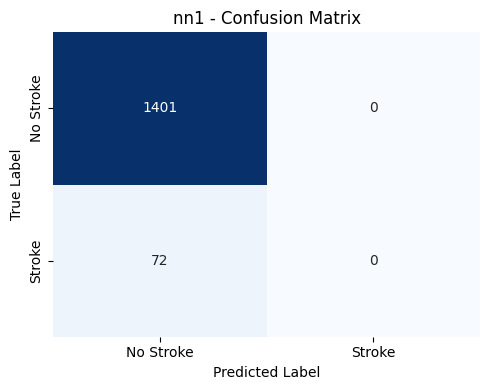


nn2 Evaluation:
Accuracy: 0.9511
F1 Score: 0.0000


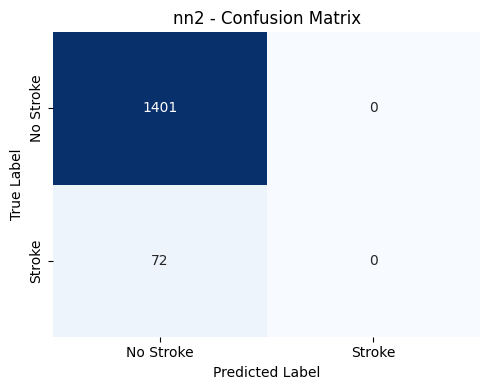


nn3 Evaluation:
Accuracy: 0.9511
F1 Score: 0.0000


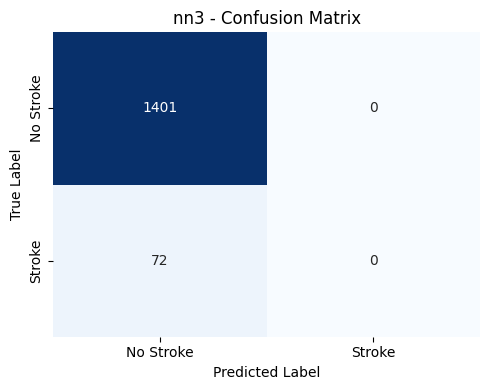


nn4 Evaluation:
Accuracy: 0.9511
F1 Score: 0.0000


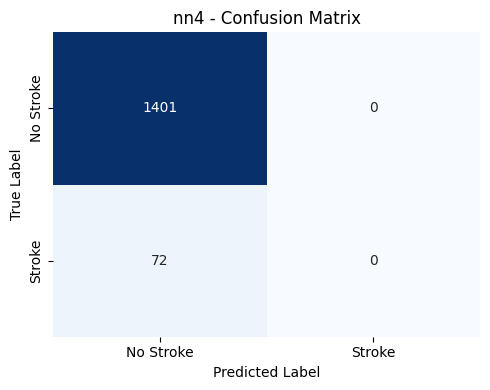


nn5 Evaluation:
Accuracy: 0.9511
F1 Score: 0.0000


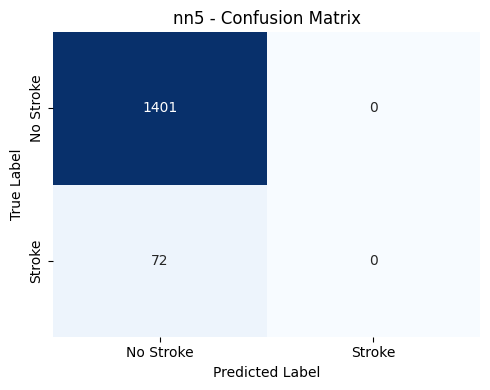


nn6 Evaluation:
Accuracy: 0.9511
F1 Score: 0.0000


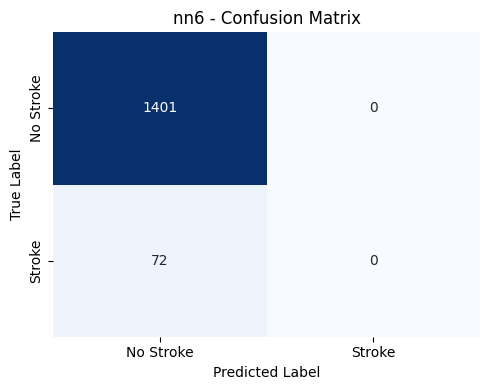


nn7 Evaluation:
Accuracy: 0.9511
F1 Score: 0.0000


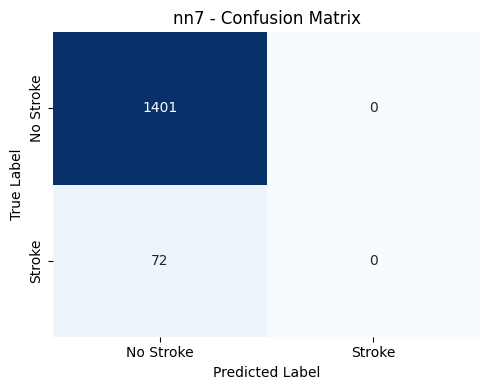


nn8 Evaluation:
Accuracy: 0.9511
F1 Score: 0.0000


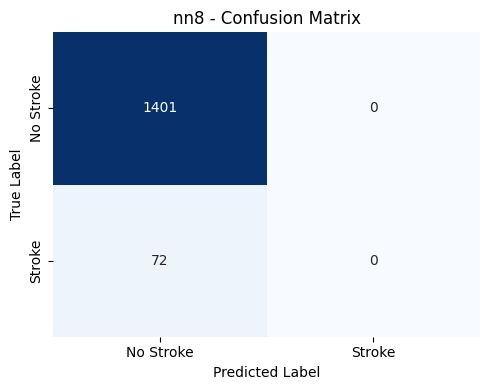


nn9 Evaluation:
Accuracy: 0.9511
F1 Score: 0.0000


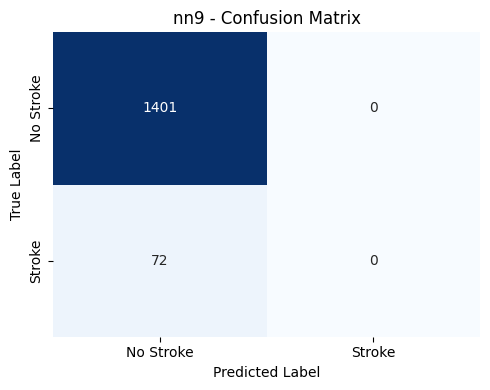

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# List of all trained neural networks
networks = [nn1, nn2, nn3, nn4, nn5, nn6, nn7, nn8, nn9]
names = [f"nn{i+1}" for i in range(len(networks))]

# Evaluate and plot
for name, nn in zip(names, networks):
    predictions = nn.predict(X_test)
    # converting continous value output into binary predictions
    y_pred = (predictions > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} Evaluation:")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Plotting the confusion matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
